In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from src.safetymaps import DesignedSafetyMap, StaticSafetyMap, DynamicSafetyMap, StaticNoisedSafetyMap
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [6]:
np.linspace(0, 1, 3)

array([0. , 0.5, 1. ])

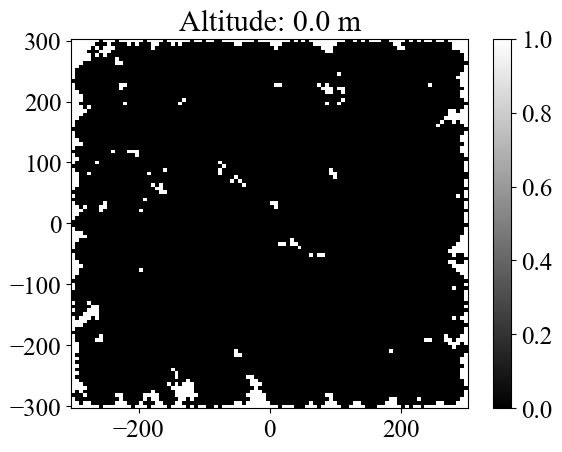

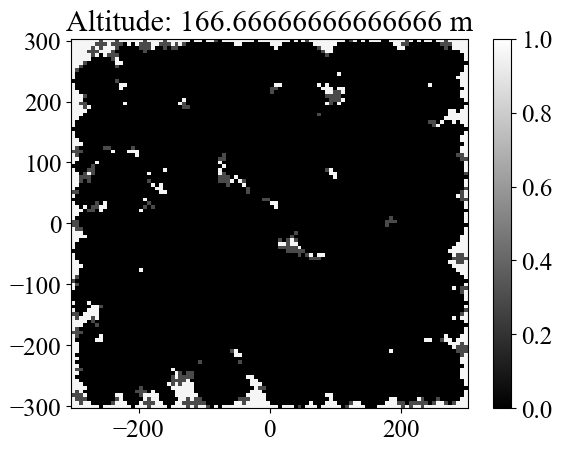

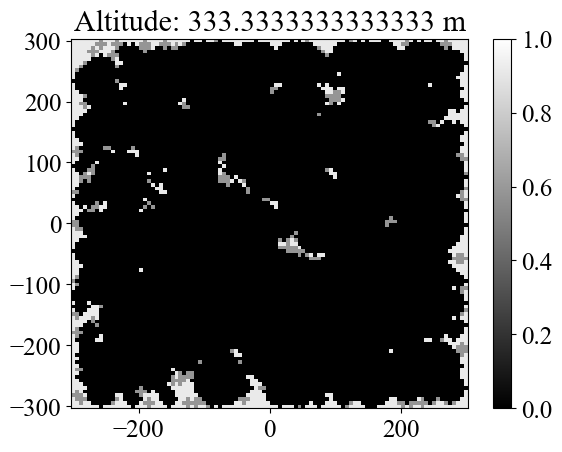

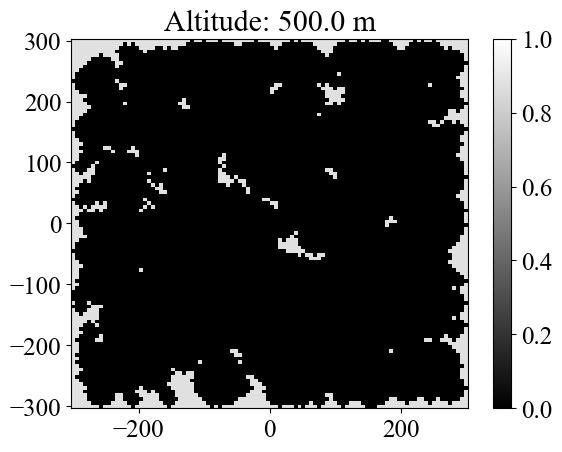

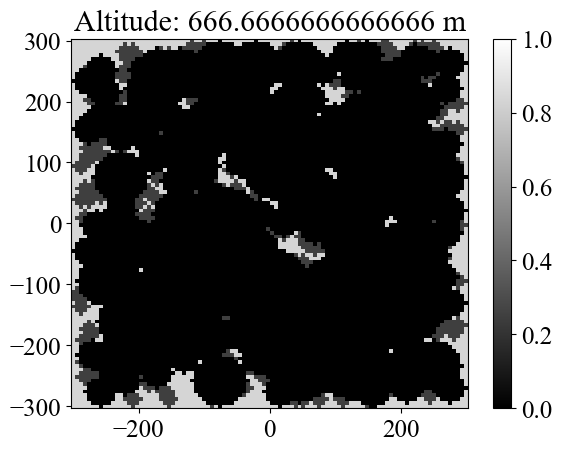

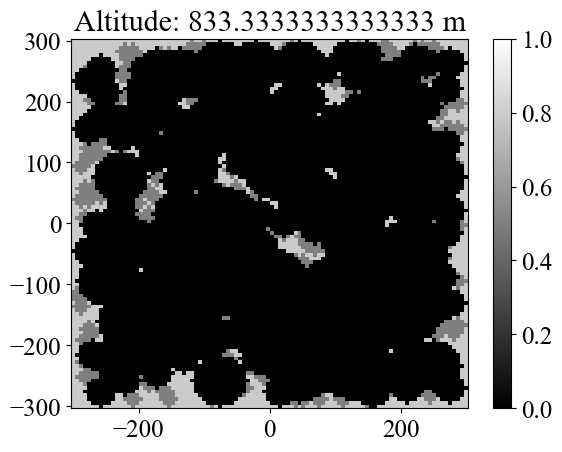

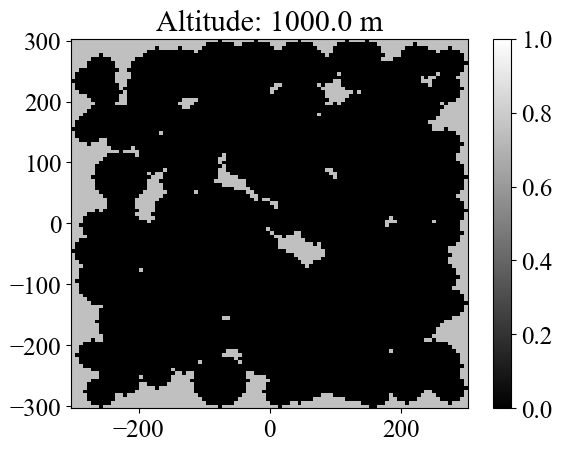

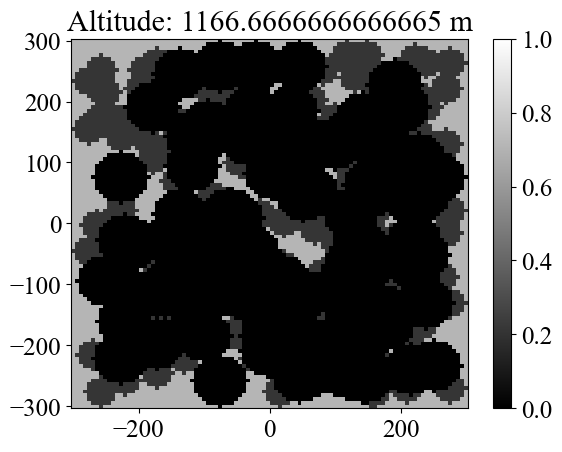

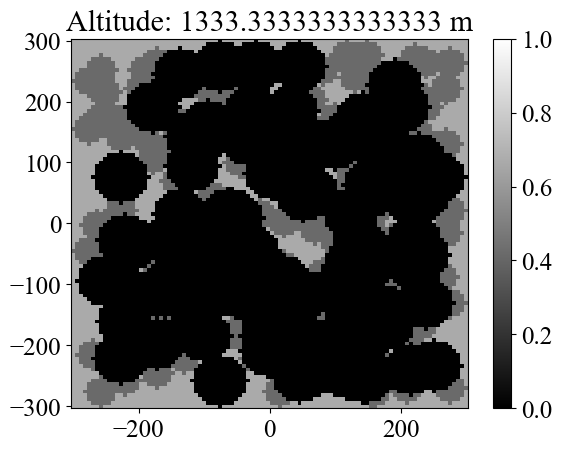

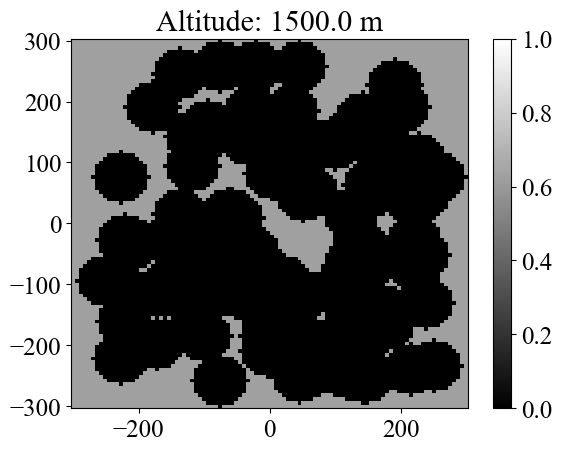

In [29]:
alt_list = np.linspace(0, 1500, 10)
npoints = 100

sfmap_model = DesignedSafetyMap(x_range=(-300, 300), y_range=(-300, 300), npoints=npoints,
                                    n_hazards=[100, 200, 500, 1000],
                                    hazard_sizes=[14, 8, 5, 2])

for alt in alt_list:
    sfmap = sfmap_model.get_sfmap(alt)
    sfmap = sfmap.reshape((npoints, npoints, 3))
    plt.figure()
    plt.pcolormesh(sfmap[:, :, 0], sfmap[:, :,1], sfmap[:, :, 2], cmap='gray', vmin=0, vmax=1)
    plt.colorbar()
    plt.title('Altitude: {} m'.format(alt))
    plt.show()
    


In [2]:
import numpy as np
import random

def generate_binary_disk_array(array_size, num_disks, disk_diameter):
    """
    Generates a 2D binary array with specified number of binary disks.

    Parameters:
    - array_size: Tuple of (height, width) of the binary array.
    - num_disks: Number of binary disks to be placed in the array.
    - disk_diameter: Diameter of each disk.

    Returns:
    - A 2D binary numpy array.
    """
    height, width = array_size
    array = np.zeros((height, width), dtype=int)
    
    radius = disk_diameter // 2

    def is_valid_position(x, y):
        """Check if the disk can be placed at the position (x, y) without overlapping."""
        for i in range(max(0, x - radius), min(height, x + radius + 1)):
            for j in range(max(0, y - radius), min(width, y + radius + 1)):
                if array[i, j] == 1 and (i - x)**2 + (j - y)**2 <= radius**2:
                    return False
        return True

    def place_disk(x, y):
        """Place a disk centered at (x, y)."""
        for i in range(max(0, x - radius), min(height, x + radius + 1)):
            for j in range(max(0, y - radius), min(width, y + radius + 1)):
                if (i - x)**2 + (j - y)**2 <= radius**2:
                    array[i, j] = 1

    placed_disks = 0
    attempts = 0
    max_attempts = 1000

    while placed_disks < num_disks and attempts < max_attempts:
        x = random.randint(radius, height - radius - 1)
        y = random.randint(radius, width - radius - 1)
        
        if is_valid_position(x, y):
            place_disk(x, y)
            placed_disks += 1
        attempts += 1

    if attempts >= max_attempts:
        print("Warning: Max attempts reached. Not all disks may have been placed.")

    return array


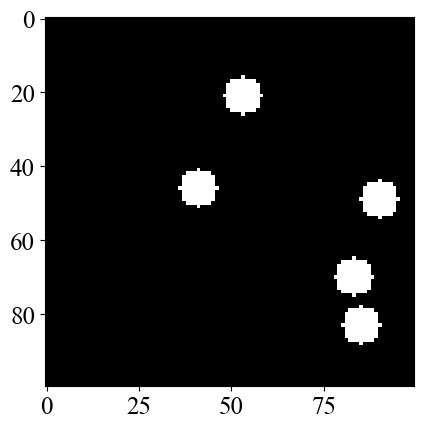

In [3]:
array_size = (100, 100)  # 100x100 array
num_disks = 5            # 5 disks
disk_diameter = 10       # Diameter of 10 pixels

binary_array = generate_binary_disk_array(array_size, num_disks, disk_diameter)

# To visualize the array, you could use matplotlib (optional)
import matplotlib.pyplot as plt
plt.imshow(binary_array, cmap='gray')
plt.show()


In [ ]:
def make_3level_sfmap(x_range, y_range, n_points):
    """Make safety map with 3 levels of hazard."""

    xmin, xmax = x_range
    ymin, ymax = y_range
    x = np.linspace(xmin, xmax, n_points)
    y = np.linspace(ymin, ymax, n_points)
    X, Y = np.meshgrid(x, y)

    sfmap = np.ones((n_points, n_points, 3))

    
    

    return sfmap, (n_points, n_points)